# Prédiction du temps de livraison — Food Delivery

**Objectif métier** : prédire `delivery_time_min` (temps de livraison, en minutes) à partir des caractéristiques de la commande, du livreur, du trafic et de la météo.

**Dataset** : `food-delivery.csv` — 45593 lignes, 20 colonnes brutes.

## Sommaire
1. Chargement et nettoyage
2. Exploration (EDA)
3. Transformation et modélisation
4. Optimisation et évaluation

## 1. Chargement et nettoyage

### 1.1 Import des librairies et chargement des données

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/food-delivery.csv")
# df.columns.tolist()
df.shape

(45593, 20)

### 1.2 Suppression des colonnes sans valeur prédictive

- `ID` : identifiant unique de la commande, aucune valeur prédictive.
- `Delivery_person_ID` : identifiant du livreur (1320 valeurs uniques).

In [2]:
df = df.drop(columns=['ID', 'Delivery_person_ID'])
df.shape

(45593, 18)

### 1.3 Renommage des colonnes

In [3]:
df = df.rename(columns={
    'Delivery_person_Age': 'delivery_person_age',
    'Delivery_person_Ratings': 'delivery_person_ratings',
    'Restaurant_latitude': 'restaurant_lat',
    'Restaurant_longitude': 'restaurant_lon',
    'Delivery_location_latitude': 'delivery_lat',
    'Delivery_location_longitude': 'delivery_lon',
    'Order_Date': 'order_date',
    'Time_Orderd': 'time_ordered',
    'Time_Order_picked': 'time_picked',
    'Weatherconditions': 'weather',
    'Road_traffic_density': 'traffic',
    'Vehicle_condition': 'vehicle_condition',
    'Type_of_order': 'order_type',
    'Type_of_vehicle': 'vehicle_type',
    'Festival': 'festival',
    'City': 'city',
    'Time_taken(min)': 'delivery_time_min',
})

df.columns.tolist()

['delivery_person_age',
 'delivery_person_ratings',
 'restaurant_lat',
 'restaurant_lon',
 'delivery_lat',
 'delivery_lon',
 'order_date',
 'time_ordered',
 'time_picked',
 'weather',
 'traffic',
 'vehicle_condition',
 'order_type',
 'vehicle_type',
 'multiple_deliveries',
 'festival',
 'city',
 'delivery_time_min']

### 1.4 Nettoyage des espaces parasites


In [4]:
columns_str = df.select_dtypes(include='str').columns
# print(columns_str)

for col in columns_str:
    df[col] = df[col].str.strip()

# for col in columns_str:
#     print(df[col].unique())
#     print('----------------')
df['traffic'].unique()

<StringArray>
['High', 'Jam', 'Low', 'Medium', 'NaN']
Length: 5, dtype: str

### 1.5 Conversion des colonnes numériques

`delivery_person_age`, `delivery_person_ratings`, `multiple_deliveries` sont en texte. Aucune valeur mal formée détectée (vérifié : pas de virgule décimale). `pd.to_numeric(errors='coerce')` convertit directement les chaînes numériques et transforme `"NaN"` en `np.nan` au passage.

In [5]:
# for col in ['delivery_person_age', 'delivery_person_ratings', 'multiple_deliveries']:
#     suspects = df[col][df[col].astype(str).str.contains(',')]
#     print(col, ':', suspects.unique())
numeric_cols = ['delivery_person_age', 'delivery_person_ratings', 'multiple_deliveries']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# print(df.info())
df[numeric_cols].isna().sum()



delivery_person_age        1854
delivery_person_ratings    1908
multiple_deliveries         993
dtype: int64

### 1.6 Traitement de la valeur aberrante dans `delivery_person_ratings`


In [6]:
df.loc[df['delivery_person_ratings'] == 6, 'delivery_person_ratings'] = np.nan
print((df['delivery_person_ratings'] == 6).sum())
print(df['delivery_person_ratings'].isna().sum())
print(df['delivery_person_ratings'].max())



0
1961
5.0


### 1.7 Correction des coordonnées GPS négatives


In [7]:
# df.columns.tolist()
df['restaurant_lat'] = df['restaurant_lat'].abs()
df['restaurant_lon'] = df['restaurant_lon'].abs()
print((df['restaurant_lat'] < 0).sum())
print((df['restaurant_lon'] < 0).sum())


0
0


### 1.8 Traitement des coordonnées placeholder


In [8]:
df.loc[(df['restaurant_lat'] == 0) & (df['restaurant_lon'] == 0), ['restaurant_lat', 'restaurant_lon']] = np.nan
df.loc[(df['delivery_lat'] == 0.01) & (df['delivery_lon'] == 0.01), ['delivery_lat', 'delivery_lon']] = np.nan

print("Restaurant coords manquantes :", df['restaurant_lat'].isna().sum())
print("Delivery coords manquantes :", df['delivery_lat'].isna().sum())



Restaurant coords manquantes : 3640
Delivery coords manquantes : 327


### 1.9 Extraction de la cible et nettoyage de la météo


In [9]:
df['delivery_time_min'] = df['delivery_time_min'].str.extract(r'(\d+)').astype(int)
df['weather'] = df['weather'].str.replace('conditions ', '', regex=False)
# df['delivery_time_min'].head()
df['weather'].unique()
print(df['weather'].isna().sum())


0


### 1.9 Correction du "NaN" textuel restant dans `weather`


In [10]:
df['weather'] = df['weather'].replace('NaN', np.nan, regex=False)
df['weather'].isna().sum()

np.int64(616)

### 1.10 Conversion des dates et heures


In [11]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y', errors='coerce')

time_ordered = pd.to_datetime(df['time_ordered'], format='%H:%M:%S', errors='coerce')
time_picked = pd.to_datetime(df['time_picked'], format='%H:%M:%S', errors='coerce')

mask_minuit = time_picked < time_ordered
time_picked = time_picked.where(~mask_minuit, time_picked + pd.Timedelta(days=1))

df['time_ordered'] = time_ordered
df['time_picked'] = time_picked

print(df[['order_date', 'time_ordered', 'time_picked']].dtypes)
print((df['time_picked'] < df['time_ordered']).sum())

order_date      datetime64[us]
time_ordered    datetime64[us]
time_picked     datetime64[us]
dtype: object
0


### 1.12 Imputation des valeurs manquantes

Conformément à la consigne du brief, l'imputation est effectuée directement à cette étape, sur l'ensemble du dataset :
- **Variables numériques** (`delivery_person_age`, `delivery_person_ratings`) : imputation par la **médiane**, robuste aux valeurs extrêmes.
- **Variables catégorielles à faible cardinalité et déséquilibrées** (`multiple_deliveries`, `festival`) : imputation par le **mode** (valeur la plus fréquente).

Les colonnes `traffic`, `city`, ainsi que les coordonnées GPS et `time_ordered`, sont traitées séparément à l'étape d'exploration (EDA), où l'analyse des fréquences et corrélations permettra un choix plus informé.

In [12]:
# Médiane pour les numériques
for col in ['delivery_person_age', 'delivery_person_ratings']:
    median = df[col].median()
    df[col] = df[col].fillna(median)

    # Mode pour les catégorielles simples
df['festival'] = df['festival'].replace('NaN', np.nan, regex=False)
print(df['festival'].unique())

for col in ['multiple_deliveries', 'festival']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print(df.isna().sum())

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
delivery_person_age           0
delivery_person_ratings       0
restaurant_lat             3640
restaurant_lon             3640
delivery_lat                327
delivery_lon                327
order_date                    0
time_ordered               1731
time_picked                   0
weather                     616
traffic                       0
vehicle_condition             0
order_type                    0
vehicle_type                  0
multiple_deliveries           0
festival                      0
city                          0
delivery_time_min             0
dtype: int64


### 1.13 Correction du "NaN" textuel dans `traffic` et `city`


In [13]:
df['traffic'] = df['traffic'].replace('NaN', np.nan)
df['city'] = df['city'].replace('NaN', np.nan)

print(df[['traffic', 'city']].isna().sum())

traffic     601
city       1200
dtype: int64


### 1.14 Imputation de `weather`, `traffic`, création de `preparation_time`, imputation de `city`


In [14]:
df['weather'] = df['weather'].fillna('Missing')
df['traffic'] = df['traffic'].fillna('Missing')

city_mode = df['city'].mode()[0]
df['city'] = df['city'].fillna(city_mode)
print("city imputé avec le mode :", city_mode)


df['preparation_time'] = (df['time_picked'] - df['time_ordered']).dt.total_seconds() / 60
print(df[['preparation_time', 'city', 'traffic', 'weather']].isna().sum())

city imputé avec le mode : Metropolitian
preparation_time    1731
city                   0
traffic                0
weather                0
dtype: int64


## 2. Exploration et analyse des dépendances (EDA)

### 2.1 Statistiques descriptives globales

Vue d'ensemble des variables numériques (moyenne, médiane, écart-type) et catégorielles (fréquences), avant toute analyse de relation avec la cible.

In [15]:
df.describe()


,delivery_person_age,delivery_person_ratings,restaurant_lat,restaurant_lon,delivery_lat,delivery_lon,order_date,time_ordered,time_picked,vehicle_condition,multiple_deliveries,delivery_time_min,preparation_time
count,45593.000000,45593.000000,41953.000000,41953.000000,45266.000000,45266.000000,45593,43862,45593,45593.000000,45593.000000,45593.000000,43862.000000
mean,29.584739,4.635040,18.911397,76.923408,17.591282,71.357417,2022-03-13 16:32:53.987235,1900-01-01 17:54:59.856368,1900-01-01 18:03:32.157568,1.023359,0.750225,26.294607,9.989399
min,15.000000,1.000000,9.957144,72.768726,0.020000,0.020000,2022-02-11 00:00:00,1900-01-01 00:00:00,1900-01-01 00:00:00,0.000000,0.000000,10.000000,5.000000
25%,25.000000,4.600000,12.986047,73.898520,12.994264,73.773613,2022-03-04 00:00:00,1900-01-01 15:25:00,1900-01-01 15:30:00,0.000000,0.000000,19.000000,5.000000
50%,30.000000,4.700000,19.065838,76.618203,18.643935,76.014212,2022-03-15 00:00:00,1900-01-01 19:15:00,1900-01-01 19:25:00,1.000000,1.000000,26.000000,10.000000
75%,34.000000,4.800000,22.751234,78.368855,22.788060,78.117151,2022-03-27 00:00:00,1900-01-01 21:35:00,1900-01-01 21:45:00,2.000000,1.000000,32.000000,15.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2022-04-06 00:00:00,1900-01-01 23:55:00,1900-01-02 00:10:00,3.000000,3.000000,54.000000,15.000000
std,5.696333,0.324598,5.467829,3.502910,7.209419,20.315410,NaN,NaN,NaN,0.839065,0.567430,9.383806,4.087516


In [16]:
categorical_cols = df.select_dtypes(include='str').columns
# print(categorical_cols.tolist())

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)
    print()






--- weather ---
weather
Fog           16.8
Stormy        16.6
Cloudy        16.5
Sandstorms    16.4
Windy         16.3
Sunny         16.0
Missing        1.4
Name: proportion, dtype: float64

--- traffic ---
traffic
Low        33.9
Jam        31.0
Medium     24.0
High        9.7
Missing     1.3
Name: proportion, dtype: float64

--- order_type ---
order_type
Snack     25.3
Meal      25.1
Drinks    24.8
Buffet    24.7
Name: proportion, dtype: float64

--- vehicle_type ---
vehicle_type
motorcycle          58.0
scooter             33.5
electric_scooter     8.4
bicycle              0.1
Name: proportion, dtype: float64

--- festival ---
festival
No     98.0
Yes     2.0
Name: proportion, dtype: float64

--- city ---
city
Metropolitian    77.4
Urban            22.2
Semi-Urban        0.4
Name: proportion, dtype: float64



### 2.2 Distribution de la variable cible (`delivery_time_min`)

Analyse de la forme de la distribution : symétrie, présence de valeurs extrêmes

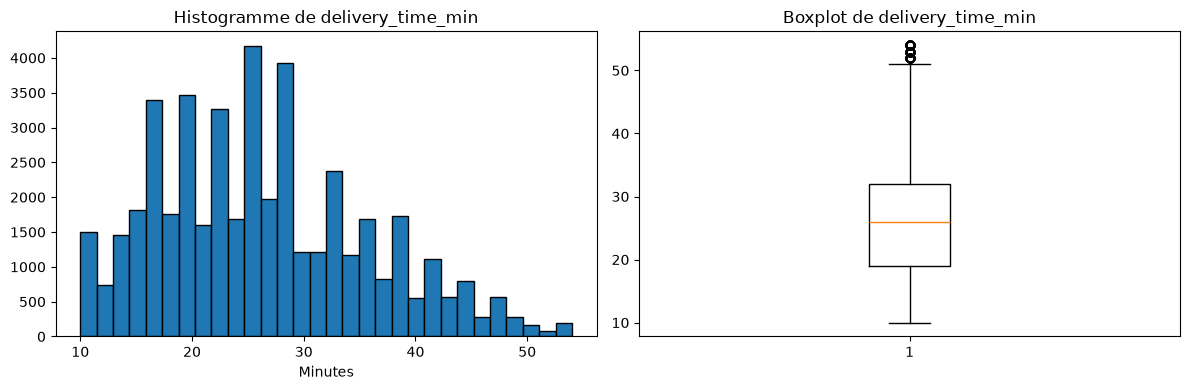

Asymétrie (skewness) : 0.4859512298743323
count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: delivery_time_min, dtype: float64


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['delivery_time_min'], bins=30, edgecolor='black')
axes[0].set_title('Histogramme de delivery_time_min')
axes[0].set_xlabel('Minutes')

axes[1].boxplot(df['delivery_time_min'])
axes[1].set_title('Boxplot de delivery_time_min')

plt.tight_layout()
plt.show()

print("Asymétrie (skewness) :", df['delivery_time_min'].skew())
print(df['delivery_time_min'].describe())

**Observations** :
- Distribution légèrement asymétrique positivement (skewness = 0,49), asymétrie faible, aucune transformation nécessaire.
- Moyenne (26,29) et médiane (26,00) très proches, confirmant une distribution raisonnablement équilibrée.
- Quelques valeurs au-delà de ~52 minutes visibles sur le boxplot, cohérentes avec le maximum observé (54 min)

### 2.3 Feature engineering

On crée deux nouvelles features, comme demandé par le brief :
1. **`distance_km`** : distance entre le restaurant et le point de livraison, calculée avec la formule de Haversine 
2. **`preparation_time`** : déjà créée à l'étape 1, ses valeurs manquantes sont imputées ici par la médiane.

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rayon de la Terre en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['restaurant_lat'], df['restaurant_lon'], df['delivery_lat'], df['delivery_lon'])

print(df['distance_km'].describe())

median_disntance = df['distance_km'].median()
df['distance_km'] = df['distance_km'].fillna(median_disntance)

median_prep_time = df['preparation_time'].median()
df['preparation_time'] = df['preparation_time'].fillna(median_prep_time)
print(df[['distance_km', 'preparation_time']].isna().sum())



count    41953.000000
mean         9.720284
std          5.603083
min          1.465067
25%          4.657655
50%          9.193021
75%         13.680920
max         20.969489
Name: distance_km, dtype: float64
distance_km         0
preparation_time    0
dtype: int64


### 2.4 Relation entre la cible et les variables numériques


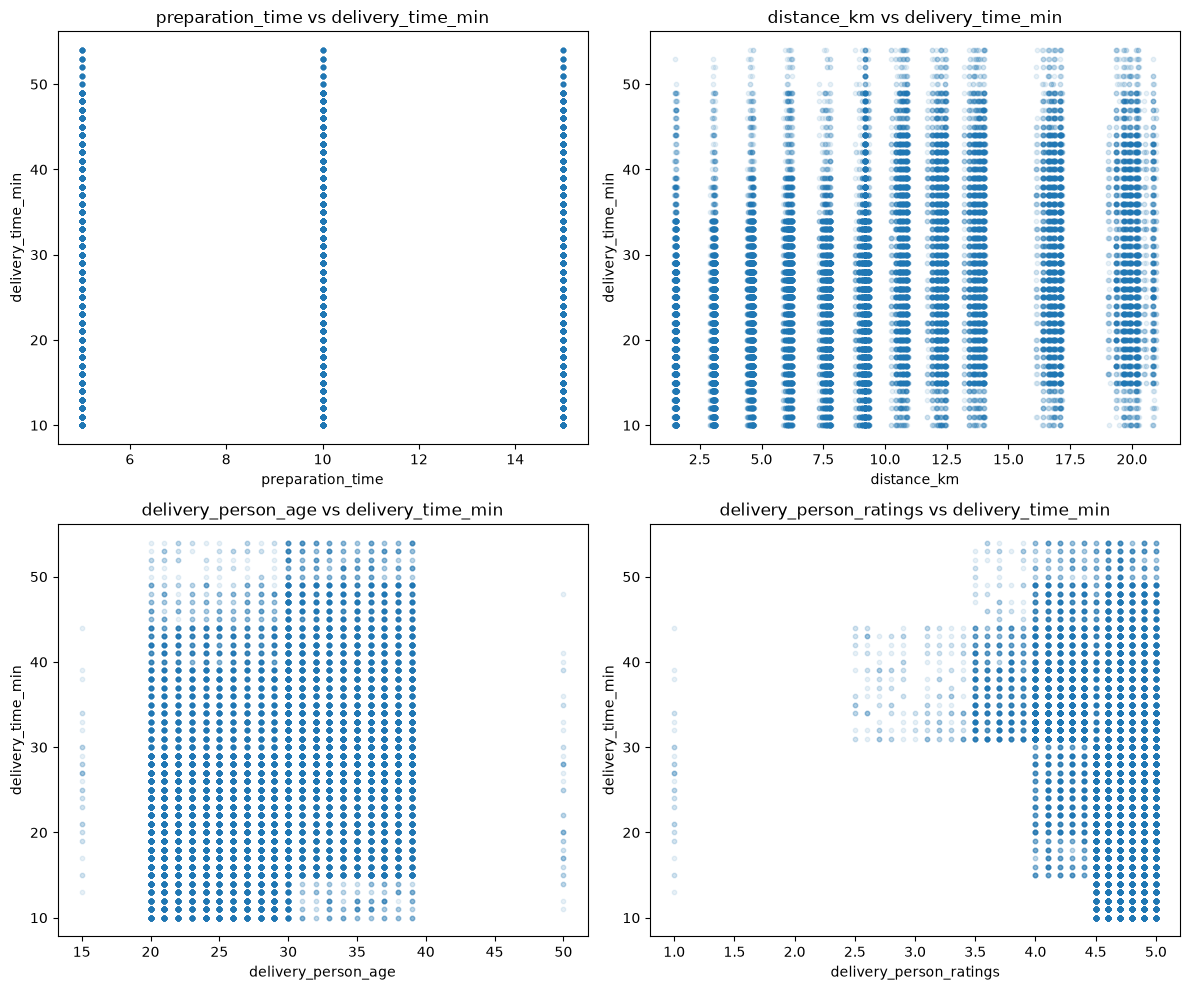

Correlation preparation_time / delivery_time_min: -0.01
Correlation distance_km / delivery_time_min: 0.31
Correlation delivery_person_age / delivery_time_min: 0.29
Correlation delivery_person_ratings / delivery_time_min: -0.33


In [19]:
numerics_vals = ['preparation_time', 'distance_km', 'delivery_person_age', 'delivery_person_ratings']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numerics_vals):
    axes[i].scatter(df[col], df['delivery_time_min'], alpha=0.1, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('delivery_time_min')
    axes[i].set_title(f'{col} vs delivery_time_min')

plt.tight_layout()
plt.show()

for col in numerics_vals:
    corr = df[col].corr(df['delivery_time_min'])
    print(f"Correlation {col} / delivery_time_min: {corr:.2f}")

### 2.5 Remplacement de `preparation_time` par des features temporelles

- **`order_hour`** : heure de la commande (0-23), pour capter d'éventuels effets d'heures de pointe.
- **`is_weekend`** : commande passée un samedi/dimanche ou non.
Les manquants de `time_ordered` (~1731) sont imputés par le **mode**

In [29]:
# df = df.drop(columns=['preparation_time'])
order_hour_mode = df['time_ordered'].dt.hour.mode()[0]
df['order_hour'] = df['time_ordered'].dt.hour.fillna(order_hour_mode)
# print(order_hour_mode)
# print(df['order_hour'].isna().sum())
# print(df['order_hour'].dtype)
df['order_hour'] = df['order_hour'].astype(int)

df['is_weekend'] = df['order_date'].dt.day_of_week.isin([5, 6])
print(df['order_hour'].dtype)
print(df['order_hour'].describe())
print(df['is_weekend'].value_counts())

int64
count    45593.000000
mean        17.559735
std          4.774677
min          0.000000
25%         15.000000
50%         19.000000
75%         21.000000
max         23.000000
Name: order_hour, dtype: float64
is_weekend
False    33054
True     12539
Name: count, dtype: int64
